![portada](images/portada.png)

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos de ejemplo
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Métricas
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [3]:
df = pd.read_csv(url, header = None, names = names)
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.nunique()

preg      17
plas     136
pres      47
skin      51
test     186
mass     248
pedi     517
age       52
class      2
dtype: int64

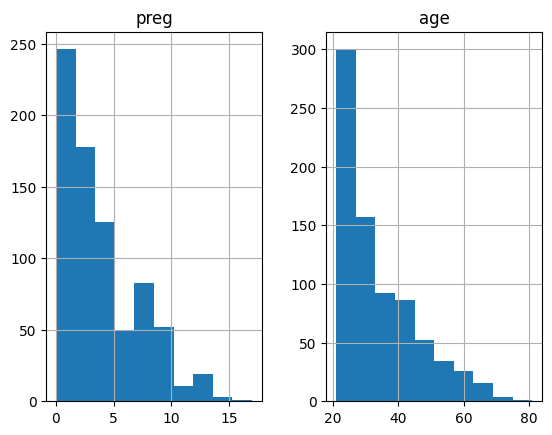

In [6]:
df[["preg", "age"]].hist();

In [7]:
df.preg.value_counts()

preg
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64

In [8]:
# vemos que la variable "preg", podría ser tanto num como cat
# la analizaremos de las dos maneras

target = "class"

In [9]:
features_num = df.columns.to_list()
features_num.remove(target)
features_num

['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

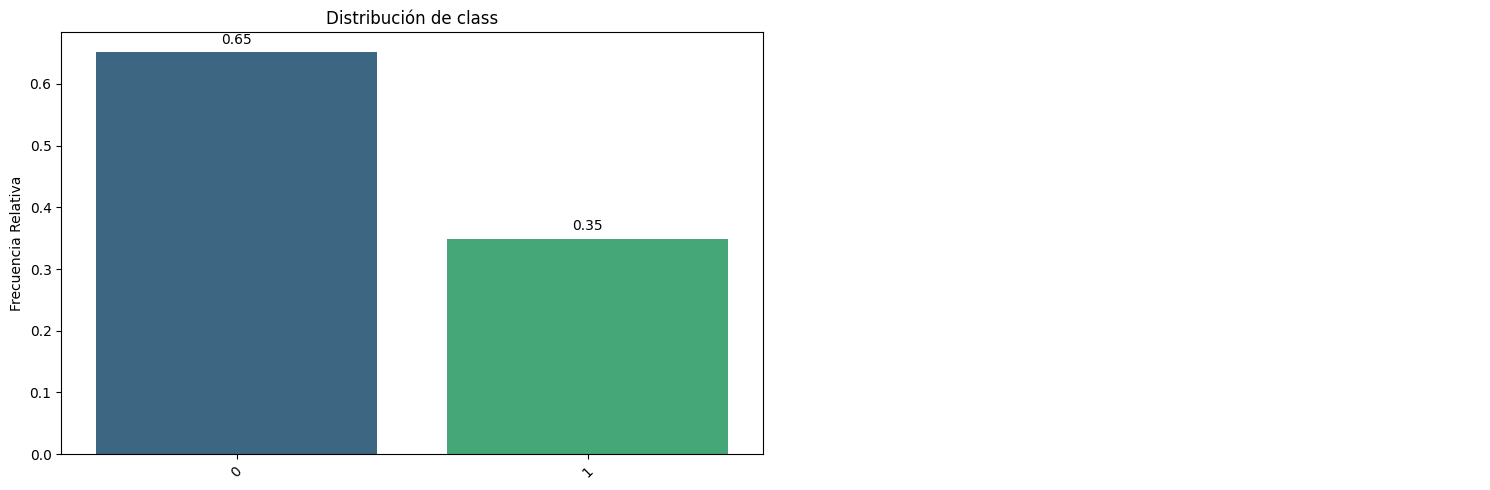

In [10]:
## veremos la distribución del target

import bootcampviztools as bt
bt.pinta_distribucion_categoricas(df, [target], mostrar_valores= True, relativa= True)

In [11]:
# el target está ligeramente desbalanceado 65-35
# lo único que haremos sería jugar un poco con un hiperparametro "class weight"

In [12]:
# Train & Test

from sklearn.model_selection import GridSearchCV

train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42)

In [13]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 60 to 102
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    614 non-null    int64  
 1   plas    614 non-null    int64  
 2   pres    614 non-null    int64  
 3   skin    614 non-null    int64  
 4   test    614 non-null    int64  
 5   mass    614 non-null    float64
 6   pedi    614 non-null    float64
 7   age     614 non-null    int64  
 8   class   614 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 48.0 KB


In [14]:
tienen_nulos = ["plas", "pres", "skin", "test", "mass"]

In [15]:
train_set[tienen_nulos] = train_set[tienen_nulos].replace(0, np.nan)
test_set[tienen_nulos] = test_set[tienen_nulos].replace(0, np.nan)

In [16]:
df[tienen_nulos].median()

plas    117.0
pres     72.0
skin     23.0
test     30.5
mass     32.0
dtype: float64

In [17]:
# Como tenemos nulos, podemos imputarle la mediana, que podría ser así:
# df.fillna(serie_medianas, axis=1)
# pero lo haremos con sklearn
# Haremos fit, solo sobre train_set y transform a ambas

from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy= "median")

train_set[tienen_nulos] = imp.fit_transform(train_set[tienen_nulos])
test_set[tienen_nulos] = imp.transform(test_set[tienen_nulos])


In [18]:
train_set[tienen_nulos].isna().sum()

plas    0
pres    0
skin    0
test    0
mass    0
dtype: int64

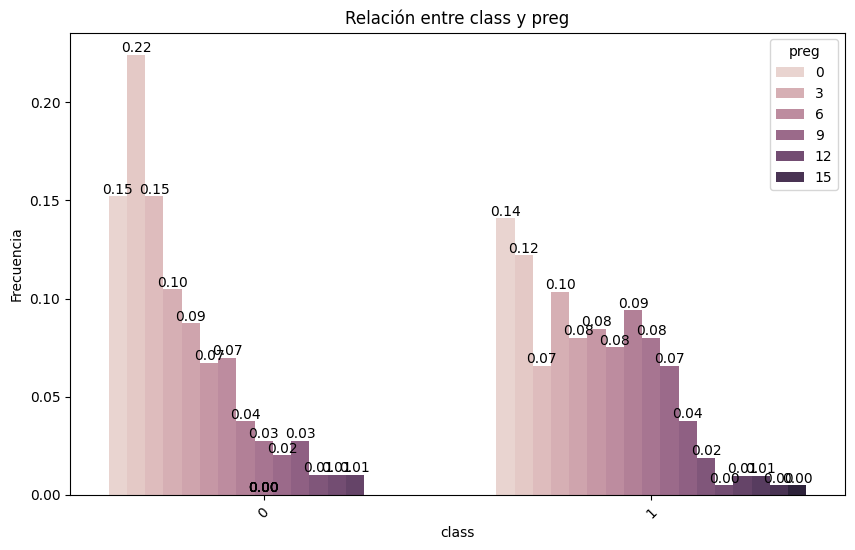

In [19]:
# Arrancamos con el analisis vs el target

bt.plot_categorical_relationship_fin(train_set, target, "preg", relative_freq= True, show_values= True)

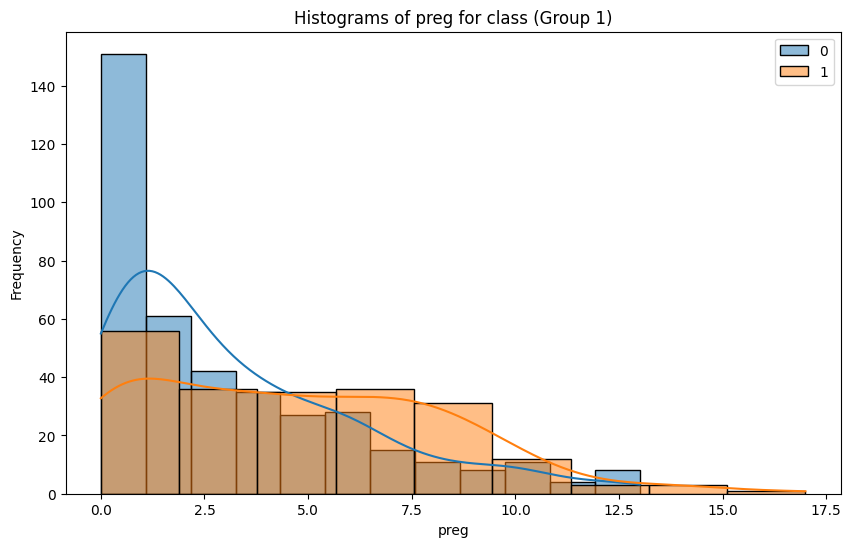

In [20]:
bt.plot_grouped_histograms(train_set, cat_col= target, num_col= "preg", group_size= 3)

In [21]:
# no vemos porque debe ser catergorica (pero tampoco me queda muy claro porque)

features_num

['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

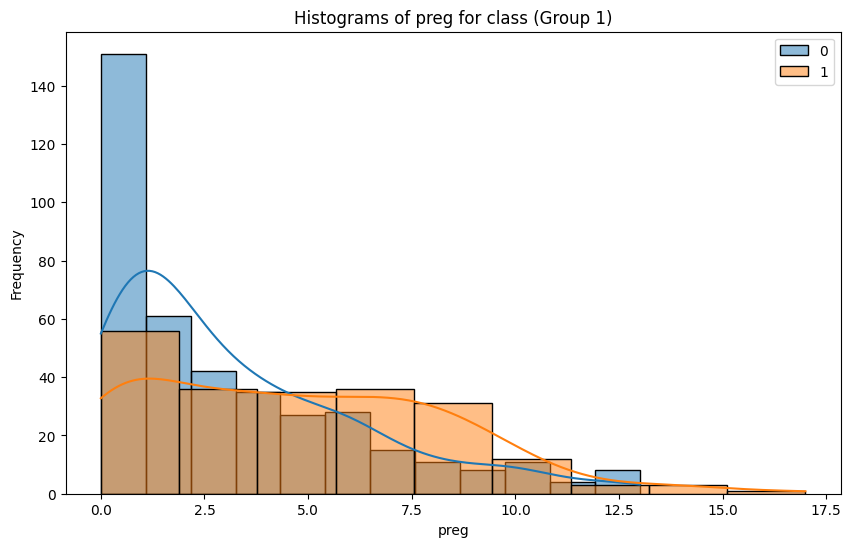

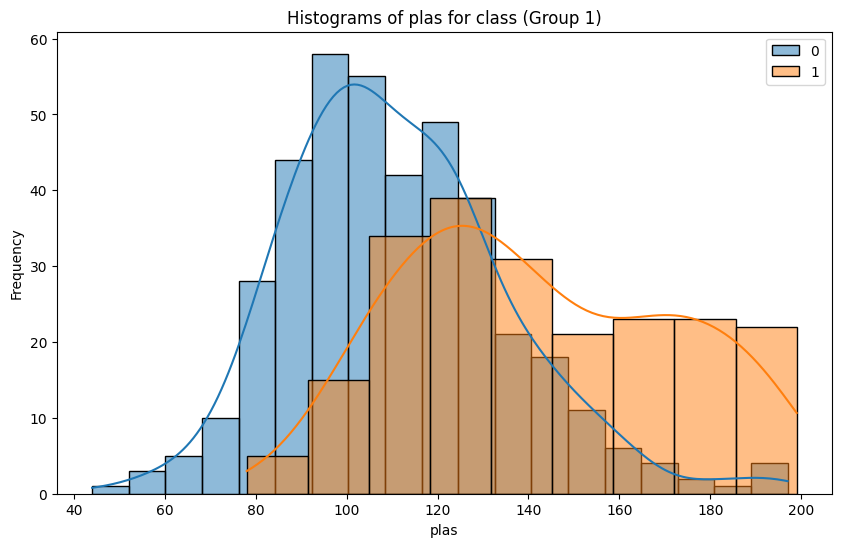

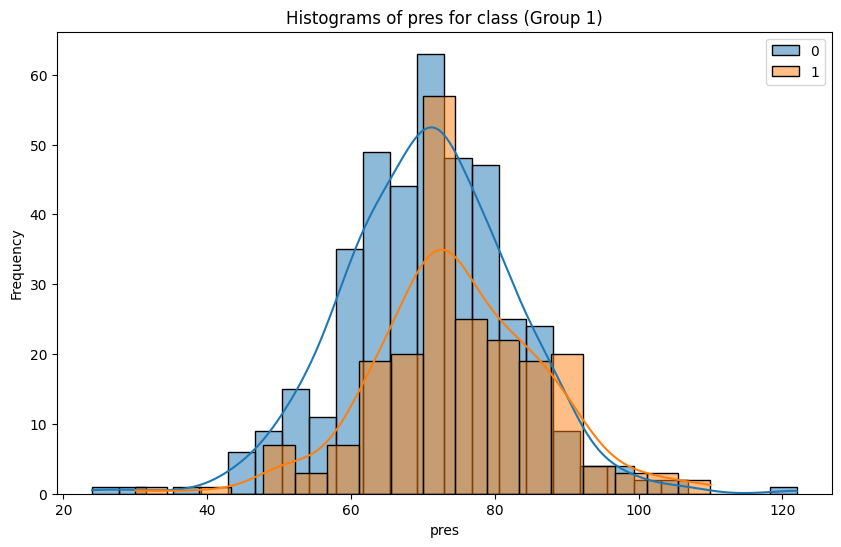

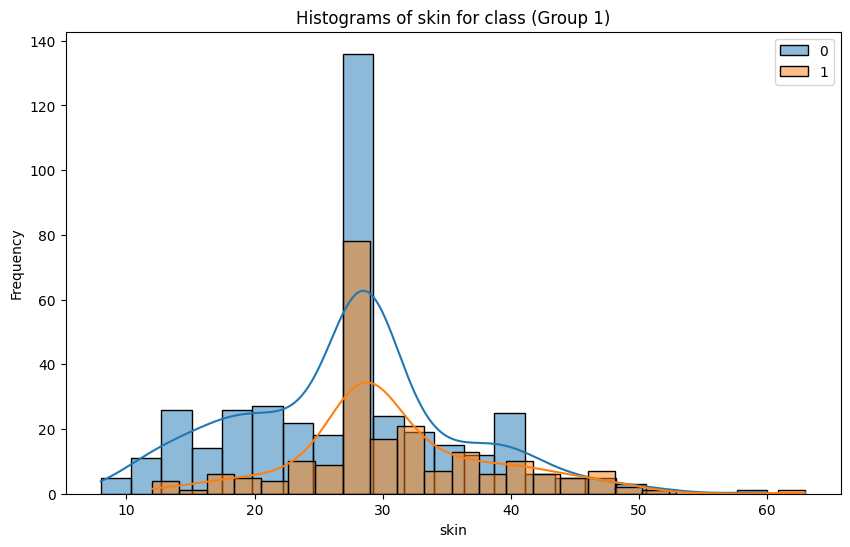

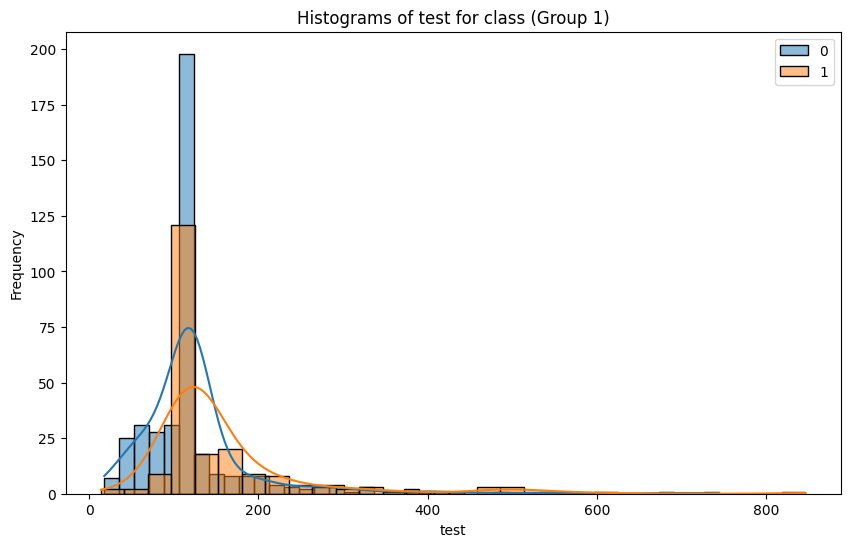

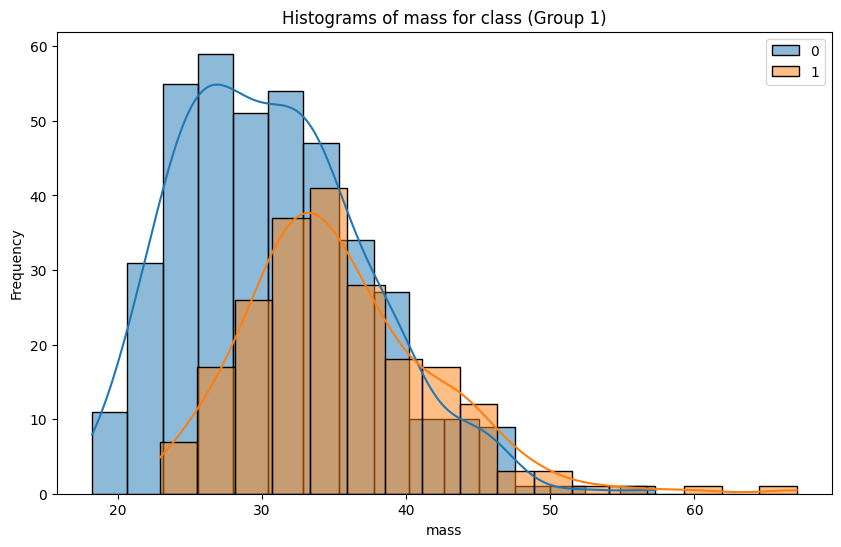

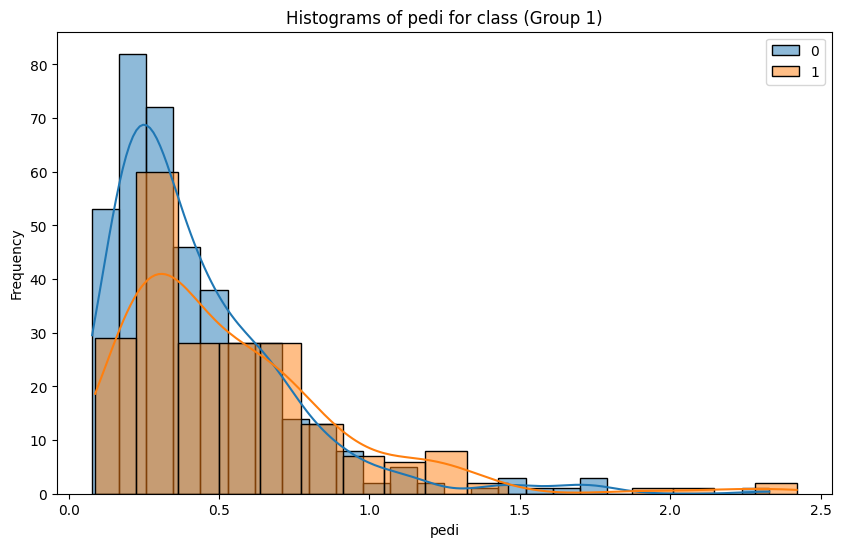

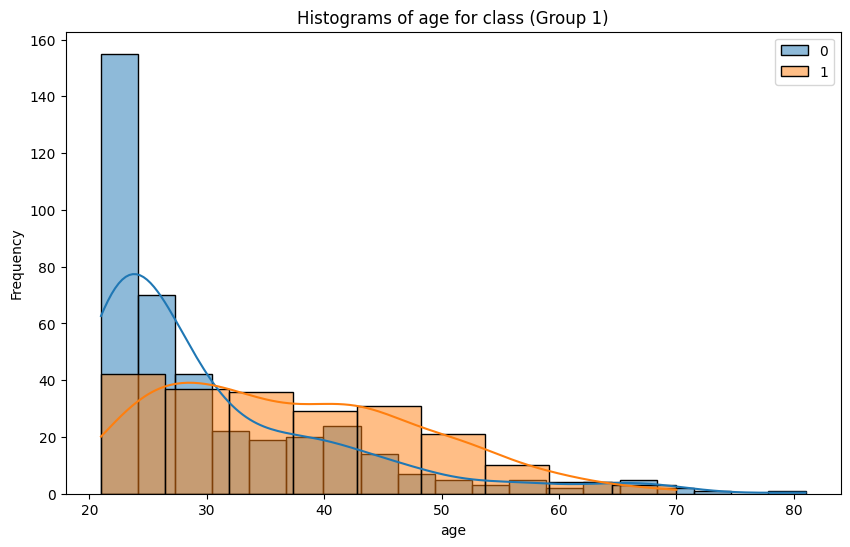

In [22]:
# sns.pairplot(train_set, hue= target)

for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 3)

In [23]:
# vamos a considerar todas, pero creermos que las más predictoras son:
# plas, mass preg (y puede que age)

In [24]:
X_train = train_set[features_num]
y_train = train_set[target]

X_test = test_set[features_num]
y_test = test_set[target]

In [25]:
X_train

,preg,plas,pres,skin,test,mass,pedi,age
60,2,84.0,72.0,28.5,120.0,32.0,0.304,21
618,9,112.0,82.0,24.0,120.0,28.2,1.282,50
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22
294,0,161.0,50.0,28.5,120.0,21.9,0.254,65
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46
...,...,...,...,...,...,...,...,...
71,5,139.0,64.0,35.0,140.0,28.6,0.411,26
106,1,96.0,122.0,28.5,120.0,22.4,0.207,27
270,10,101.0,86.0,37.0,120.0,45.6,1.136,38
435,0,141.0,72.0,28.5,120.0,42.4,0.205,29


In [26]:
import sys, subprocess
print("python:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "show", "xgboost"])



python: c:\Users\helad\OneDrive\Escritorio\DataSience\DS-Online-Roman\venv\Scripts\python.exe


CompletedProcess(args=['c:\\Users\\helad\\OneDrive\\Escritorio\\DataSience\\DS-Online-Roman\\venv\\Scripts\\python.exe', '-m', 'pip', 'show', 'xgboost'], returncode=0)

In [28]:
from sklearn.ensemble import RandomForestClassifier # bagging - boostrap aggregation
from xgboost import XGBClassifier # boosting
from lightgbm import LGBMClassifier # boosting

base_clf = RandomForestClassifier(max_depth = 5, random_state= 42)

In [29]:
cross_val_score(base_clf, X_train, y_train, cv= 5, scoring= "balanced_accuracy")

array([0.68738977, 0.76482558, 0.71031977, 0.69244186, 0.73630952])

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

print("Recall medio:", np.mean(cross_val_score(base_clf, X_train, y_train, cv= 5, scoring= "balanced_accuracy")))

Recall medio: 0.7182573007669907


In [31]:
base_clf

RandomForestClassifier(max_depth=5, random_state=42)

In [32]:
base_clf.fit(X_train, y_train) # para el feature Importance

RandomForestClassifier(max_depth=5, random_state=42)

In [33]:
print(classification_report(y_train, base_clf.predict(X_train)))

              precision    recall  f1-score   support

           0       0.86      0.93      0.90       401
           1       0.85      0.72      0.78       213

    accuracy                           0.86       614
   macro avg       0.86      0.83      0.84       614
weighted avg       0.86      0.86      0.86       614



In [34]:
base_clf.feature_importances_

array([0.05549472, 0.33800084, 0.04584832, 0.04984747, 0.10507137,
       0.17583607, 0.07477862, 0.15512259])

In [35]:
base_clf.feature_names_in_

array(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'],
      dtype=object)

In [36]:
pd.DataFrame({"features": base_clf.feature_names_in_, "importance": base_clf.feature_importances_}).sort_values("importance", ascending= False)

,features,importance
1,plas,0.338001
5,mass,0.175836
7,age,0.155123
4,test,0.105071
6,pedi,0.074779
0,preg,0.055495
3,skin,0.049847
2,pres,0.045848


In [37]:
# Bagging - RandomForest
# Boosting - XGBoost LightGBM

In [38]:
xgb_clf = XGBClassifier(max_depth= 5,
                        random_state= 42)

lgb_clf = LGBMClassifier(max_depth= 5,
                         random_state= 42,
                         verbose= -1,
                         n_jobs= -1)

In [39]:
for nombre, modelo in zip(["Random Forest", "XGboost", "LightGBM"], [base_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end = " ")
    print("Recall medio:", np.mean(cross_val_score(modelo, X_train, y_train, cv= 5, scoring= "balanced_accuracy")))

Para Random Forest: Recall medio: 0.7182573007669907
Para XGboost: Recall medio: 0.7171196320905624
Para LightGBM: Recall medio: 0.7258451253024896


In [40]:
# Nos quedamos con XGBoost

In [41]:
train_set[train_set[target] == 0]

,preg,plas,pres,skin,test,mass,pedi,age,class
60,2,84.0,72.0,28.5,120.0,32.0,0.304,21,0
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22,0
294,0,161.0,50.0,28.5,120.0,21.9,0.254,65,0
340,1,130.0,70.0,13.0,105.0,25.9,0.472,22,0
718,1,108.0,60.0,46.0,178.0,35.5,0.415,24,0
...,...,...,...,...,...,...,...,...,...
20,3,126.0,88.0,41.0,235.0,39.3,0.704,27,0
700,2,122.0,76.0,27.0,200.0,35.9,0.483,26,0
71,5,139.0,64.0,35.0,140.0,28.6,0.411,26,0
106,1,96.0,122.0,28.5,120.0,22.4,0.207,27,0


In [42]:
train_set

,preg,plas,pres,skin,test,mass,pedi,age,class
60,2,84.0,72.0,28.5,120.0,32.0,0.304,21,0
618,9,112.0,82.0,24.0,120.0,28.2,1.282,50,1
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22,0
294,0,161.0,50.0,28.5,120.0,21.9,0.254,65,0
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46,1
...,...,...,...,...,...,...,...,...,...
71,5,139.0,64.0,35.0,140.0,28.6,0.411,26,0
106,1,96.0,122.0,28.5,120.0,22.4,0.207,27,0
270,10,101.0,86.0,37.0,120.0,45.6,1.136,38,1
435,0,141.0,72.0,28.5,120.0,42.4,0.205,29,1


In [45]:
# haremos un balanceo "manual"

len(train_set[train_set[target] == 0])/len(train_set[train_set[target] == 1])

1.8826291079812207

In [46]:
### XGBoost

param_grid = {
    "n_estimators": [100,200,400],
    "eta": [0.1,0.3,0.6,1], # learning rate
    "max_depth": [1,6,10,None], # Stumps
    "min_child_weight": [1,10,20,100],
    "scale_pos_weight": [len(train_set[train_set[target] == 0])/len(train_set[train_set[target] == 1]), 1], # class weight
    "colsample_bytree": [0.5, 1] # max_features sqrt,
}

xgb_clf = XGBClassifier()

xgb_grid = GridSearchCV(xgb_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring= "balanced_accuracy",
                        n_jobs= -1)

xgb_grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.5, 1],
                         'eta': [0.1, 0.3, 0.6, 1],
                         'max_depth': [1, 6, 10, None],
                         'min_child_weight': [1, 10, 20, 100],
                         'n_estimators': [100, 200, 400],
                         'scale_pos_weight': [1.8826291079812207, 1]},
             scoring='balanced_accuracy')

In [47]:
xgb_best = xgb_grid.best_estimator_
xgb_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eta=0.1, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=1,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, ...)

In [48]:
xgb_grid.best_params_

{'colsample_bytree': 1,
 'eta': 0.1,
 'max_depth': 1,
 'min_child_weight': 1,
 'n_estimators': 200,
 'scale_pos_weight': 1.8826291079812207}

In [49]:
xgb_grid.best_score_

np.float64(0.7820971248103031)

In [ ]:
best_params = xgb_grid.best_params_ # por si queremos reentrenar modelos (ajustando parametremos que fueron buenos en su momento)

In [51]:
xgb_optimizrd_model = XGBClassifier(**best_params, random_state= 42)
xgb_optimizrd_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eta=0.1, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=1,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, ...)

In [52]:
xgb_optimizrd_model.predict(X_test)

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

In [53]:
print(classification_report(y_test, xgb_optimizrd_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.69      0.76        99
           1       0.58      0.78      0.67        55

    accuracy                           0.72       154
   macro avg       0.72      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154

